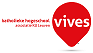<br>


**INTRODUCTION TO ARTIFICIAL INTELLIGENCE**<br>
Academiejaar 2021-2022<br>
Stefaan Haspeslagh<br>
Andy Louwyck<br>
Pieter Ideler

---



---



#**INTRODUCTION TO MACHINE LEARNING IN PYTHON**

Deze notebook is een korte introductie in het oplossen van machine learning problemen met Python. We geven enkele voorbeelden van supervised en unsupervised learning:

- lineaire regressie (supervised)
- classificatie met K Nearest Neighbors (supervised)
- K-Means clustering (unsupervised)
- image classification met neurale netwerken (supervised)

## Python libraries

We hebben de volgende libraries nodig:
- NumPy: library voor numeriek rekenen
- Pandas: library voor het analyseren van data
- MatplotLib: library voor het visualiseren van data
- Pillow: library voor het bewerken van images
- Scikit-Learn: machine learning library
- TensorFlow + Keras: deep learning library

We importeren deze libraries met het `import` commando. Het is gebruikelijk om NumPy alias `np` te geven en Pandas alias `pd`. Van MatplotLib hebben we de `pyplot` module nodig; de conventie is om die als `plt` te importeren.

In [ ]:
import numpy as np  # numeric python
import pandas as pd  # python data analysis library
import PIL  # python imaging library
import matplotlib.pyplot as plt  # python library for visualizations
plt.rcParams["figure.dpi"] = 100  # figuren groter maken

Van Scikit-Learn, TensorFLow en Keras importeren we enkel de klassen die we nodig hebben op het moment dat we ze nodig hebben. 

## Lineaire regressie

Lineaire regressie is een vorm van supervised learning waarbij de target, d.i. de feature die we voorspellen, een kwantitatieve variabele is. Bovendien veronderstellen we dat er een lineair verband is tussen de overige features die we gebruiken om de target te voorspellen. 

De eenvoudigste vorm van lineaire regressie is die waarbij we een target $y$ proberen te voorspellen a.d.h.v. 1 feature $x$. Dit noemen we **enkelvoudige lineaire regressie**. In dit geval kunnen we de datapunten voorstellen in een tweedimensionaal assenstelsel. Het toepassen van lineaire regressie komt dan neer op het vinden van de **best passende rechte**.

We weten dat de algemene vergelijking van een rechte gelijk is aan: 

> $y=ax+b$

Om de best passende rechte te vinden passen we een algoritme toe dat a.d.h.v. de datapunten $(x_i, y_i)$ richtingscoëfficiënt $a$ en intercept $b$ afleidt. Eens de waarden voor **parameters** $a$ en $b$ zijn gevonden, beschikken we over een **model** waarmee we voorspellingen kunnen doen. Dat doen we door in de gevonden vergelijking een nieuwe waarde $x$ in te vullen om zo de voorspelling $\hat{y}$ te bekomen.

**Voorspelling** $\hat{y}$ zal uiteraard niet gelijk zijn aan de echte waarde $y$, maar we weten wel dat het verschil (of de fout) tussen voorspelde en echte waarde minimaal is, omdat het algoritme waarden voor $a$ en $b$ heeft afgeleid door de fouten van alle datapunten in de dataset te minimaliseren. Dit minimaliseren van de verschillen, ook wel de **loss** genaamd, is het **trainen** van het model.

Er bestaan verschillende **algoritmes** om lineaire regressie toe te passen. En we kunnen ook meer dan 1 feature $x$ gebruiken om $y$ te voorspellen. Als we bijvoorbeeld beschikken over 2 features $x_1$ en $x_2$, dan zoeken we het best passende vlak in een driedimensionaal assenstelsel. Bij meer dan 2 features zoeken we een hypervlak in een n-dimensonale ruimte. We kunnen ook niet-lineaire verbanden modelleren met polynomiale regressie. Maar dit zijn allemaal topics die uitvoerig aan bod zullen komen in het vak Machine Learning Fundamentals.

In deze notebook beperken we ons tot 2 voorbeeldjes waarin we enkelvoudige lineaire regressie toepassen. In elk voorbeeld lezen we eerst een dataset in als Pandas dataframe, en we visualiseren de datapunten in een scatterplot m.b.v. Matplotlib. Daarna gebruiken we klasse `LinearRegression` van Scikit-Learn om de best passende rechte te vinden en enkele voorspellingen te maken met het gevonden model.



In [ ]:
from sklearn.linear_model import LinearRegression

### Voorbeeld 1

In het eerste voorbeeld bestuderen we de leeftijd van koppels. Concreet proberen we de leeftijd van de vrouw te voorspellen aan de hand van de leeftijd van de man. Intuïtief zouden we kunnen stellen dat de leeftijd van de partners gemiddeld genomen gelijk zal zijn. Hoe drukken we dat wiskundig uit? 

Aangezien we de leeftijd van de vrouw willen voorspellen is dit de target $y$. De leeftijd van de man is dan feature $x$. Ons intuïtieve model heeft dan eenvoudigweg de volgende vergelijking:

> $y = x$

Richtingscoëfficiënt $a$ is hier dus 1, en intercept $b$ is 0. 

Stel nu dat we ervan uit zouden gaan dat de vrouw gemiddeld genomen 1 jaar jonger is dan de man, dan krijgen we het volgend model:

> $y = x - 1$

In dit geval zijn de parameters $a$ en $b$ respectievelijk gelijk aan 1 en -1.

Zo kunnen we blijven raden naar de beste waarden voor parameters $a$ en $b$. Maar dat is niet hoe we in machine learning te werk gaan. Nee, in machine learning gaan we data verzamelen en dan een algoritme op die data loslaten om zo de beste waarden voor onze parameters te vinden. Laten we dat eens doen!

De data hebben we al verzameld en de dataset is opgeslagen in de file `"leeftijd_koppel.xlsx"`. Dit is een Excelfile, maar gelukkig voorziet Pandas een functie `read_excel` waarmee we eenvoudig een tabel uit een Excelbestand kunnen inladen als `DataFrame`:

In [ ]:
df = pd.read_excel('leeftijden_koppel.xlsx')
df.head()

Met de methode `head` printen we de eerste 5 records uit ons dataframe op. Je ziet dat een dataframe gewoon een tabel is. De kolommen zijn de **features**, de rijen de datapunten of **examples**. Om te weten hoeveel datapunten in onze dataset zitten, kunnen we gewoon functie `len` toepassen op ons `DataFrame` object:

In [ ]:
len(df)  # lengte van een dataframe = aantal rijen

We hebben dus 25 examples en 3 features. Maar uitaard is kolom `"Couple"` gewoon een index waar we geen nuttige informatie uit kunnen halen. Die kolom kunnen we dus negeren. De andere twee kolommen zijn de leeftijden van man en vrouw. Die hebben we nodig! Laten we die leeftijden eens tegenover elkaar uitzetten in een scatterplot. We willen de leeftijd van de vrouw voorspellen, dus die komt op de y-as te staan. De x-as is dan de leeftijd van de man:

In [ ]:
husband, wife = tuple(df.columns[1:])  # kolomnamen in variabelen stoppen
df.plot.scatter(x=husband, y=wife)  # scatter plot maken mbv methode plot.scatter
y = x = np.linspace(0, 100, 100)
plt.plot(x, y, 'k--')  # lijn y = x
plt.grid()  # grid toevoegen aan de grafiek

We hebben ook ons intuïtief model $y=x$ geplot en we zien dat dit geen slechte gok is! Benieuwd welk model het machine learning algoritme zal afleiden... Voor de duidelijkheid stoppen we eerst feature en target in aparte variabelen, en we zetten ze om naar NumPy arrays: 

In [ ]:
X = df[husband].values.reshape(-1, 1)  # feature x
y = df[wife].values  # target y

Geen paniek als je niet volledig snapt wat hier gebeurt... Deze syntax wordt uitvoerig uitgelegd in de vervolgvakken Programming in Python en Machine Learning Fundamentals!

Om lineaire regressie toe te passen, moeten we de `LinearRegression` klasse instantiëren. Daarna 'trainen' we het model door de methode `fit` aan te roepen met variabelen `X` en `y` als input. Het is deze methode die de parameters $a$ en $b$ zal afleiden door de datapunten te **fitten**:

In [ ]:
model = LinearRegression()  # LinearRegression object creëren
model.fit(X, y)  # model trainen = data fitten

We kunnen nu ook nagaan hoe goed het algoritme de datapunten heeft gefit door methode `score` aan te roepen:

In [ ]:
model.score(X, y)  # berekent de R² score van het model

In het geval van lineaire regressie is deze score de determinatiecoëfficiënt R². In het vak Machine Learning Fundamentals wordt uitgelegd hoe die juist wordt berekend. Hier volstaat het te onthouden dat R² een getal tussen 0 en 1 is, en hoe dichter de score bij 1 ligt, hoe beter het model is. We kunnen ook onze parameters $a$ en $b$ opvragen:

In [ ]:
a, b = model.coef_[0], model.intercept_  # rico a en intercept b
a, b

We zien dat het algoritme andere waarden voor $a$ en $b$ heeft afgeleid. Laten we het resultaat eens plotten:

In [ ]:
X_line = np.linspace(0, 100, 100)
y_line = a * X_line + b  # rechte afgeleid door het algoritme
df.plot.scatter(x=husband, y=wife)
plt.plot(X_line, X_line, 'k--', X_line, y_line, 'r-')
plt.legend(['intuïtief', 'ML model', 'data'])
plt.grid()

Het ML model zal de leeftijd van de vrouw dus iets lager inschatten dan dat van haar man. Laten we dat eens checken met enkele nieuwe datapunten. Stel dat we 2 nieuwe koppels hebben waarvan de man respectievelijk 40 en 80 jaar oud is. Met methode `predict` kunnen we nu eenvoudig de leeftijd van hun vrouw voorspellen:

In [ ]:
X_new = np.array([[40],   # man van 40
                  [80]])  # man van 80
model.predict(X_new)

Het model voorspelt dat de respectievelijke leeftijd van de vrouwen (afgerond) 38 en 75 jaar zal zijn. Zijn die voorspellingen ok? Wel, het is een zeer kleine dataset, en dus zijn die voorspellingen niet betrouwbaar. In praktijk zorgen we daarom best voor een veel grotere dataset, zodat we die kunnen opsplitsen in een training-, validatie- en testset. Op die manier kunnen we overfitting voorkomen en ons model grondig evalueren. Hoe we dat doen wordt uitvoerig uitgelegd in het vak Machine Learning Fundamentals!

### Voorbeeld 2

De tweede dataset is er één uit Zweden. Het bevat voor verschillende regio's uit dat land het aantal schadeclaims die bij verzekeringsmaatschappijen zijn ingediend, en het totale bedrag dat zij hebben uitbetaald (in 1000 Zweede kronen). Uiteraard is het voor die verzekeringsmaatschappijen heel nuttig om dat bedrag te kunnen voorspellen als ze het nieuwe aantal schadeclaims weten. Een ideale case om enkelvoudige lineaire regressie toe te passen!

Lees de file `"auto_insurance_sweden.csv"` in. Dit is een csv-file die je in pandas makkelijk kan inlezen met de functie `read_csv`. Pas op! In de file werd geen komma, maar een puntkomma gebruikt als scheidingsteken, dus je moet naast de naam van de file een extra inputparameter `sep=";"` meegeven met de functie. Stop het `DataFrame` object geretourneerd door de functie in variabele `df`, en print de eerste 5 lijnen uit m.b.v. methode `head`:

Hoeveel datapunten bevat de dataset?

We stoppen de kolomnamen in variabelen:

In [ ]:
claims, payment = tuple(df.columns)

Maak een scatterplot van de data:

Zet feature en target om naar NumPy arrays, en stop ze in variabelen `X` en `y`, respectievelijk:

Pas nu lineaire regressie toe:

 Bereken de R² score:

Stop de parameters in variabelen `a` en `b`:

Maak opnieuw de scatterplot en voeg er de bekomen regressielijn aan toe:

Wat zal het totaal bedrag zijn dat de verzekeringen moeten uitbetalen als er 80, 100 en 140 schadeclaims zijn?

## K Nearest Neighbors

De "K Nearest Neighbors" algoritmen (KNN) zijn zeer bekend in machine learning en kennen ook heel veel toepassingen. Ze kunnen gebruikt worden bij classificatie, regressie en zelfs bij unsupervised learning. Wij beperken ons hier tot 2 voorbeeldjes van **classificatie**.

Het "nearest neighbors" principe is vrij simpel: het algoritme neemt de K datapunten uit de trainingset die het dichtst bij een nieuw datapunt liggen, en in het geval van classificatie geeft het dat nieuwe datapunt het label dat het meest voorkomt bij de K omringende datapunten.

Vraag is alleen: hoe vindt het algoritme de K dichtstbijzijnde datapunten? Het anwoord is: door de afstanden tussen het nieuwe datapunt en de datapunten in de trainingset te berekenen. Dat kan de Manhattan afstand zijn, maar heel vaak wordt ook de Euclidische afstand gebruikt, wat de afstand in vogelvlucht is tussen 2 punten. 

Neem 2 punten met respectievelijke coördinaten $(x_1, y_1)$ en $(x_2, y_2)$, dan is de **Manhattan afstand** $m$:

> $m = |x_2 - x_1| + |y_2 - y_1|$

De **Euclidische afstand** $d$ vinden we door toepassing van de stelling van Pythagoras:

> $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$



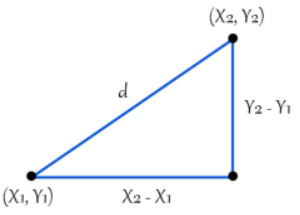

In machine learning zijn de coördinaten de features, en dus berekent het algoritme de verschillen tussen de features van de datapunten. Om onze resultaten grafisch te kunnen voorstellen, beperken we ons hier tot datapunten met 2 features $x_1$ en $x_2$ en een label $y$. Maar uiteraard kan het algoritme ook toegepast worden op datapunten met meer dan 2 features. In het vak Machine Learning Fundamentals leggen we uit hoe dat in zijn werk gaat.

Net als bij lineaire regressie beperken we ons hier opnieuw tot 2 eenvoudige voorbeeldjes, waarin we telkens een kleine dataset als Pandas dataframe inlezen, de datapunten in een scatterplot uitzetten, en dan de klasse van enkele nieuwe datapunten voorspellen. Omdat het hier om classificatie gaat, moeten we klasse `KNeighborsClassifier` van Scikit-Learn gebruiken:



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In tegenstelling tot lineaire regressie en de meeste andere machine learning modellen, is er geen trainingfase bij KNN. De waarde voor K geven wij zelf op (het is dus een **hyperparameter**), en dus hoeft het algoritme geen parameters af te leiden. Daarom noemen we dit **lazy learning**.

### Voorbeeld 1

We starten met een dataset die van 100 vrouwen en 100 mannen de lengte in cm en het gewicht in kg bevat. Gemiddeld genomen zijn vrouwen iets kleiner en lichter dan mannen. Kunnen we nu a.d.h.v. deze dataset voorspellen of iemand man of vrouw is o.b.v. diens lengte en gewicht? Laten we dat eens proberen door KNN toe te passen.

We lezen eerst de csv-file `"lengte_gewicht_gender.csv"` in. Merk op dat deze file een komma als scheidingsteken gebruikt, dus we kunnen gewoon de naam van de file doorgeven aan functie `read_csv`:  

In [ ]:
df = pd.read_csv("lengte_gewicht_gender.csv")
df.head()

De eerste 5 examples bevatten gegevens van vrouwen. Dat zien we aan het label `'v'`. Mannen krijgen dan waarschijnlijk het label `'m'`. Laten we dat eens checken door methode `unique` aan te roepen op kolom `df.gender`: 

In [ ]:
df.gender.unique()  # methode unique geeft de unieke waarden

Met de methode `describe` kunnen we trouwens de statistieken opvragen van de numerieke features:

In [ ]:
df.describe()

Om de gemiddelde lengte en het gemiddelde gewicht van mannen en vrouwen afzonderlijk te weten, kunnen we net zoals in SQL gebruik maken van methode `groupby`:

In [ ]:
df.groupby('gender').mean()  # methode mean berekent het gemiddelde

We zien inderdaad dat de vrouwen in de dataset gemiddeld kleiner en lichter zijn dan de mannen.

Laten we de data eens visualiseren in een scatterplot, waarbij we de datapunten een kleur geven o.b.v. de labels. Hier concreet gaan we de punten van mannen blauw kleuren, en die van vrouwen krijgen de kleur magenta:

In [ ]:
_, ax = plt.subplots()
df.loc[df.gender=='v', :].plot.scatter(x='lengte', y='gewicht', c='m', ax=ax);  # mannen: blauw
df.loc[df.gender=='m', :].plot.scatter(x='lengte', y='gewicht', c='b', ax=ax);  # vrouwen: magenta
plt.grid()

We zien dat er inderdaad 2 duidelijke groepen zijn. Er is weliswaar wat overlapping tussen beide groepen, maar ze zijn wel van elkaar te scheiden. Het is dus mogelijk om a.d.h.v. deze dataset te voorspellen of iemand vrouw of man is wanneer we de lengte en het gewicht van die persoon kennen.

De interface van de `KNeighborsClassifier` klasse is dezelfde als die van klasse `LinearRegression`. Dus we gaan opnieuw de features en de labels in respectievelijk NumPy arrays `X` en `y` stoppen. We moeten de labels wel nog omzetten naar integers, omdat het algoritme enkel met getallen kan rekenen. Dat doen we door label `'v'` te vervangen door `1` en label `'m'` door `0`:

In [ ]:
X = df[['lengte', 'gewicht']].values  # features lengte en gewicht in matrix X stoppen
y = (df.gender=="v").values.astype(int)  # kolom df.gender met labels omzetten naar boolean vector y met enen en nullen

In NumPy en Pandas kunnen we bewerkingen uitvoeren op volledige arrays zonder gebruik te maken van lussen! Voor meer details hierover en voor uitleg over de Pandas syntax die hier wordt toegepast, verwijzen we naar het vak Programming in Python.

Nu zijn we klaar om het KNN algoritme toe te passen. Eerst moeten we klasse `KNeighborsClassifier` instantiëren. Zoals we hierboven al hebben uitgelegd, moeten we K zelf opgeven. Dat doen we hier a.d.h.v. inputparameter `n_neighbors`, die we gelijk stellen aan 5:

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)  # K = 5
model.fit(X, y)

Hierboven hebben we gezegd dat we geen model moeten trainen wanneer we KNN toepassen. Maar we natuurlijk wel onze data doorgeven aan het `KNeighborsClassifier` object, en dus moeten we toch methode `fit` aanroepen.

Net als bij lineaire regressie kunnen we ook ons model evalueren door methode `score` aan te roepen. Maar omdat we hier met classificatie te maken hebben, krijgen we de nauwkeurigheid (Engels: **accuracy**) van het model. Dat is eenvoudigweg het aantal correct geclassificeerde datapunten gedeeld door het totaal aantal punten:

In [ ]:
model.score(X, y)  # berekent de nauwkeurigheid van het model

95.5% van de datapunten wordt dus correct geclassificeerd door het KNN algoritme!

Laten we nu eens proberen te voorspellen of de volgende personen man of vrouw zijn:
- persoon van 165 cm en 55 kg
- persoon van 185 cm en 70 kg
- persoon van 175 cm en 65 kg

In [ ]:
X_new = np.array([[165, 55],   # persoon van 165cm en 55kg
                  [185, 70],   # persoon van 185cm en 70kg
                  [175, 65]])  # persoon van 175cm en 65kg
model.predict(X_new)

De eerste 2 personen zijn vrij duidelijk, maar de derde persoon is een twijfelgeval. Om te zien waarom het model voor 'man' kiest, maken we opnieuw de scatterplot, maar we voegen er nu ook de 3 nieuwe punten aan toe:

In [ ]:
_, ax = plt.subplots()
df.loc[df.gender=='v', :].plot.scatter(x='lengte', y='gewicht', c='m', ax=ax);  # mannen: blauw
df.loc[df.gender=='m', :].plot.scatter(x='lengte', y='gewicht', c='b', ax=ax);  # vrouwen: magenta
plt.plot(X_new[:, 0], X_new[:, 1], 'yo')  # nieuwe punten in geel toevoegen
plt.grid()

Omdat we K = 5 hebben genomen, kijkt het KNN algoritme naar de 5 punten die het dichtst liggen van een nieuw punt. De derde persoon komt overeen met het middelste gele punt. Van de 5 dichtste punten zijn er inderdaad 4 blauw en slechts 1 roze, dus het nieuwe punt krijgt ook een blauwe kleur, wat inderdaad overeenkomt met label `'m'`. 

### Voorbeeld 2

In een tweede voorbeeld gaan we proberen te voorspellen of een persoon die op een social network site zit al dan niet zal ingaan op een advertentie die op die site wordt weergegeven. M.a.w. we gaan voorspellen of iemand het product zal kopen of de advertentie zal negeren. Om dat te kunnen voorspellen maken we gebruik van de leeftijd en het geschatte loon van die persoon. 

Dit is opnieuw een voorbeeld van **binaire classificatie**, omdat we 2 klassen hebben: personen die het product kopen, en personen die het product niet kopen. En omdat het een classificatieprobleem is, kunnen we opnieuw het KNN algoritme toepassen.

De dataset die we gaan gebruiken is opgeslagen in file `"Social_Network_Ads.csv"`. Lees die file in en toon de 5 eerste rijen:

Kolom `"User Id"` bevat geen informatie en kolom `"Gender"` gaan we niet gebruiken. De features zijn dus `"Age"` en `"EstimatedSalary"`, en het label is `"Purchased"`. Check of die laatste kolom effectief uit nullen en enen bestaat:

Maak nu een scatterplot en kleur de punten van personen die het product gekocht hebben in groen (`'g'`) en de punten van personen die het product niet gekocht hebben in rood (`'r'`):

Stop nu de features in NumPy array `X` en de labels in NumPy array `y`:

Pas nu het KNN algoritme toe met K = 3:

Welke nauwkeurigheid heeft het model?

Voorspel nu of de volgende personen het product al dan niet gaan kopen:
- persoon van 25 jaar met ca 60.000 als loon
- persoon van 40 jaar met ca 85.000 als loon
- persoon van 55 jaar met ca 100.000 als loon


Maak opnieuw een scatterplot en voeg de nieuwe datapunten toe in blauw (`'b'`). Check of de berekende labels kloppen. Vergeet niet dat we deze keer de 3 dichtstbijzijnde punten hebben genomen (K =  3)!

## K-Means clustering

In de vorige voorbeeldjes over classificatie waren de datasets gelabeld. Concreet was er telkens een kolom in het dataframe die aangaf tot welke klasse een datapunt behoorde. Het labelen van datasets is echter tijdrovend, en het zou dus nuttig zijn moesten we dat ook aan een algoritme kunnen overlaten. En die algoritmes bestaan! We noemen ze clustering algoritmes, omdat ze zelf de data in **clusters** opdelen. Ze worden dus vaak toegepast voor het preprocessen van de data.

In dit hoofdstuk demonstreren we één van de bekendste clustering algoritmes: K-Means clustering. Het idee achter dit algoritme is als volgt. Het algoritme kiest willekeurig K punten, die we **centroïden** noemen, omdat het elk van die punten in het centrum één van de K clusters gaat plaatsen. Hoe doet het algoritme dat? Eerst berekent het de afstand van alle punten tot de centroïden en het kent elk punt toe aan de cluster met de centroïde waar het het dichtst bij ligt. Daarna verplaatst het elke centroïde naar het centrum van de eigen cluster. Het berekent dan opnieuw de afstanden tussen alle datapunten en de nieuwe centroïden, verdeelt de datapunten opnieuw over de clusters, en herberekent de positie van de centroïden. Het algoritme blijft dit herhalen tot de centroïden niet meer bewegen en de datapunten in hun definitieve cluster zitten.

Als voorbeeld passen we K-Means clustering toe op de datasets uit het hoofdstuk over K Nearest Neighbors. We gebruiken hiervoor de klasse `KMeans` van Scikit-Learn: 

In [ ]:
from sklearn.cluster import KMeans

Deze keer gaan we dus geen gebruik maken van de kolom met labels, maar laten het algoritme "**unsupervised**" de data opdelen in groepen. We moeten wel zelf het aantal clusters K opgeven. Net als bij KNN is dit dus een **hyperparameter**. De afstandsmaat kunnen we ook kiezen, maar we maken opnieuw gebruik van de **Euclidische afstand**.

### Voorbeeld 1

We lezen opnieuw de dataset `"lengte_gewicht_gender.csv"` in en zetten de datapunten uit in een scatterplot. Omdat we hier geen gebruik zullen maken van de labels in kolom `"gender"`, geven we alle punten dezelfde kleur:

In [ ]:
df = pd.read_csv("lengte_gewicht_gender.csv")
df.plot.scatter(x='lengte', y='gewicht')
plt.grid()

We hebben enkel de features `"lengte"` en `"gewicht"` nodig. Die zetten we opnieuw om naar een NumPy array `X`:

In [ ]:
X = df[['lengte', 'gewicht']].values

Om het K-means algoritme toe te passen, moeten we klasse `KMeans` instantiëren. Het aantal clusters K moeten we zelf opgeven via inputparameters `n_clusters`. We weten dat er 2 klassen zijn, en daarom geven we 2 op als inputargument. Het algoritme bepaalt willekeurig de initiële positie van de centroïden, en dus maakt het gebruik van een random number generator. Via inputparameters `random_state` kunnen we de seed van die generator opgeven:

In [ ]:
model = KMeans(n_clusters=2, random_state=20)  # K = 2
model.fit(X)

Wat opvalt is dat we inderdaad enkel matrix `X` met features moeten opgeven, en geen array `y` met labels, omdat het een unsupervised learning algoritme is!

Als we nu de labels willen weten, dan kunnen we `X` doorgeven aan methode `predict`:

In [ ]:
yp = model.predict(X)  # de voorspelde labels

Pas op! Het kan zijn dat het algoritme de klassen een andere id heeft gegeven, want het kent natuurlijk de ids niet die in de dataset worden gebruikt! Om dat te checken halen we toch de labels uit de dataset en stoppen ze in variabele `y`, waarna we de nauwkeurigheid berekenen:

In [ ]:
y = (df.gender=="v").values.astype(int)  # de echte labels
(y == yp).sum() / len(y)  # de nauwkeurigheid = aantal correct voorspelde labels gedeeld door totaal aantal datapunten

96% van de labels zijn correct voorspeld. Hadden we 4% als uitkomst gekregen, dan moesten we de labels als volgt omdraaien:

```python
b = yp == 1
yp[b] = 0
yp[~b] = 1
```

Laten we nu ook eens voorspellen of de 3 nieuwe personen met gekende lengte en gekend gewicht man of vrouw zijn:

In [ ]:
X_new = np.array([[165, 55],   # persoon van 165cm en 55kg
                  [185, 70],   # persoon van 185cm en 70kg
                  [175, 65]])  # persoon van 175cm en 65kg
model.predict(X_new)

De derde persoon behoort nu tot de cluster met vrouwen! Om te zien hoe dat komt, maken we opnieuw een scatterplot met daarop de 3 nieuwe datapunten. Om dat effeciënt te kunnen doen, voegen we de voorspelde labels toe aan het dataframe:

In [ ]:
df['voorspelling'] = np.array(['m', 'v'])[yp]  # 'm' is 0 en 'v' is 1
df.head()

We maken nu 2 scatterplots: op de ene zijn de punten ingekleurd volgens de echte labels (links), op de andere volgens de clusters (rechts):

In [ ]:
_, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharey=True)
df.loc[df.gender=='v', :].plot.scatter(x='lengte', y='gewicht', c='m', ax=ax1)
df.loc[df.gender=='m', :].plot.scatter(x='lengte', y='gewicht', c='b', ax=ax1)
ax1.plot(X_new[:, 0], X_new[:, 1], 'yo')
ax1.set_title("echte labels")
ax1.grid()
df.loc[df.voorspelling=='v', :].plot.scatter(x='lengte', y='gewicht', c='m', ax=ax2)
df.loc[df.voorspelling=='m', :].plot.scatter(x='lengte', y='gewicht', c='b', ax=ax2)
ax2.plot(X_new[:, 0], X_new[:, 1], 'yo')
ax2.set_title("cluster labels")
ax2.grid()

De derde persoon komt overeen met het middelste gele punt. Op de rechter plot zien we dat de 2 clusters niet overlappen en dat dit punt inderdaad nog net in de cluster met roze punten ligt.

### Voorbeeld 2

Probeer nu zelf eens K-means clustering uit op de dataset `"Social_Network_Ads.csv"`. Lees het bestand in en maak een scatterplot zonder rekening te houden met de labels:

Stop de kolommen met features `"Age"` en `"EstimatedSalary"` in NumPy array `X`:

Pas K-means toe met K = 2:  

Laat het model de labels voorspellen van de punten in de dataset:

Bereken de nauwkeurigheid door de voorspelde labels te vergelijken met de echte labels:

Voorspel nu opnieuw of de volgende personen het product al dan niet gaan kopen:
- persoon van 25 jaar met ca 60.000 als loon
- persoon van 40 jaar met ca 85.000 als loon
- persoon van 55 jaar met ca 100.000 als loon


Voeg de voorspellingen toe aan het dataframe in een nieuwe kolom `"Prediction"`:  

Maak een scatterplot die de echte labels en de cluster labels weergeeft. Voeg ook de nieuwe datapunten toe aan de plots:

## Image classification

In dit laatste hoofdstuk van deze notebook maken we kennis met **deep learning**, en meer bepaald met Keras, een Python library waarmee we vlot **artificiële neurale netwerken** kunnen bouwen, trainen en evalueren. 

Neurale netwerken zijn geïnspireerd door de werking van biologische hersenen. Ze bestaan ook uit **neuronen** die met elkaar zijn verbonden en zo signalen uitwisselen met elkaar. De neuronen in biologische hersenen versterken of verzwakken die signalen. In een artificieel neuraal netwerk zijn de signalen de features die ook worden versterkt of verzwakt in elk neuron waar de gewogen som van de input wordt getransformeerd door een **activatiefunctie**. De gewichten die worden gebruikt in de gewogen som zijn de **parameters** van het model, in dit geval het neurale netwerk.

Een klassiek neuraal netwerk bestaat uit verschillende lagen, waarvan de inputlaag de features van de data ontvangt, en doorgeeft naar de inwendige verborgen lagen, die de features transformeren, om uiteindelijk uit te komen in de outputlaag, die de voorspellingen doet. Het algoritme is ook hier een **optimizer** die iteratief de parameters aanpast door de **loss functie** te minimaliseren. Herinner je dat de loss functie een maat is voor het verschil tussen voorspelde en echte labels.

Neurale netwerken zijn zeer succesvol in computer vision. Vooral de **convolutionele netwerken** (CNNs of convnets) blijken zeer efficiënt te zijn in het herkennen van patronen in images. Dit zullen we hier demonstreren met een klassiek voorbeeld van **image classification**: het classificeren van handgeschreven cijfers uit de MNIST dataset. Eerst zullen we een netwerk met traditionele "dense layers" trainen op de dataset, en daarna zullen we de performantie proberen te verbeteren door gebruik te maken van een netwerk met "convolutional layers". De neuronen in zo'n laag berekenen geen gewogen som, maar passen een wiskundige bewerking toe die we convolutie noemen. Diezelfde bewerking wordt ook toegepast om bijvoorbeeld foto's waziger of scherper te maken. Denk maar aan het toepassen van filters in Instagram. Eenvoudig gezegd leidt een convnet uit de gegeven images zelf de beste filters af waarmee het lijnen, kleuren, texturen en objecten kan "herkennen". Op basis daarvan kan het dan de images gaan classificeren.

In het vak Deep Learning zullen we dieper ingaan op al deze technische details. Hier willen we jullie enkel de kracht en efficiëntie van neurale netwerken zelf eens laten ervaren. Zet alvast jullie hardware accelerator op GPU! (In Google Colab doe je dit via menu "Edit > Notebook settings".)

###MNIST dataset

De [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database) is beschikbaar in Keras en kan je downloaden via `datasets.mnist`:

In [ ]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

Er vallen ons direct 2 zaken op:
- De dataset is volgens de regels van de kunst opgesplitst in een trainingset en een testset. We zullen de neurale netwerken enkel trainen op de trainingset en nadien evalueren met de testset. 
- Image classificatie is net als alle andere classificatietaken een vorm van **supervised learning**. Dus we hebben niet alleen de images nodig, maar ook de bijhorende labels. 

Laten we eens checken hoeveel examples er in de dataset zitten: 

In [ ]:
print(f"De trainingset bevat {len(train_images)} images")
print(f"De testset bevat {len(test_images)} images")

In totaal 70.000 images... Dat is al wat anders dan de datasets uit onze vorige voorbeeldjes! Laten we nu even kijken hoe de dataset is opgebouwd. Nemen we als voorbeeld de vijfde image uit de trainingset:

In [ ]:
digit = train_images[4]  # 5de image (index 4!)
plt.imshow(digit, cmap=plt.cm.binary)  # image plotten
plt.title(f"Label: {train_labels[4]}");  # label van 5de image

De images hebben een size van 28 op 28 pixels. Het zijn zwart-wit images, dus er is maar 1 kanaal voor de grijswaarde. Elke pixel is een feature en dus moeten we de images "reshapen". Hier concreet moeten we alle pixels van een image achter elkaar zetten, zodat ze één lange rij vormen. De verschillende images zetten we dan onder elkaar en zo krijgen we weer een tabel met in de rijen de examples, hier dus de images, en in de kolommen de features, hier dus de 28 x 28 = 784 pixels.

Bovendien moeten we de pixelwaarden, die integers zijn tussen 0 en 255, herschalen naar floats tussen 0 en 1. Dat doen we eenvoudig door de waarden te delen door 255:

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))  # reshapen
train_images = train_images.astype("float32") / 255  # herschalen en omzetten naar float
test_images = test_images.reshape((10000, 28 * 28))  # reshapen
test_images = test_images.astype("float32") / 255  # herschalen en omzetten naar float

### Eigen cijfer

Om de proef op de som te nemen, hebben we een eigen handgeschreven cijfer als image `"image.png"` opgeslagen. We lezen de image in met de statische methode `open` van klasse `Image` uit de Pillow library, die we als `PIL` hebben geïmporteerd. We krijgen dan een `Image` object die we kunnen "resizen" naar 28 op 28 pixels en omzetten naar een zwart-wit image. Omdat een image in feite niks anders is dan een matrix met de pixelwaarden, kunnen we die zonder problemen converteren naar een NumPy array, waarvan we de waarden makkelijk kunnen omzetten naar float waarden tussen 0 en 1:

In [ ]:
cijfer = PIL.Image.open("cijfer.png")  # image inlezen
cijfer = cijfer.resize((28, 28))  # image resizen naar 28 x 28
cijfer = cijfer.convert('L')  # image omzetten naar zwart-wit (L = luminance)
cijfer = np.array(cijfer)  # image omzetten naar numpy array
cijfer = 255 - cijfer  # zwart wordt wit, wit wordt zwart
cijfer = cijfer.astype("float32") / 255.0  # array herschalen
plt.imshow(cijfer, cmap=plt.cm.binary);  # cijfer plotten

Dat ziet er goed uit! Benieuwd of onze neurale netwerken het cijfer zullen herkennen...

###Dense neural network

We gaan nu eerst een netwerk opbouwen dat bestaat uit 'klassieke' `Dense` layers. Eerst importeren we `keras`, dat nu een onderdeel is van `tensorflow`:

In [ ]:
from tensorflow import keras

Nu bouwen we een zogenaamd `Sequential` model dat bestaat uit een opeenvolging van lagen. Wij zullen 3 lagen definiëren:
- De *inputlaag* die de omgezette images accepteert. De inputsize is dus `(None, 784)`, waarbij de `None` verwijst naar het aantal images die tijdens één iteratie van het algoritme worden verwerkt. Dat aantal noemt men de *batch size*.
- Een *verborgen laag* die uit 512 neuronen bestaat en de `"relu"` functie als activatiefunctie toepast.
- De *outputlaag* die uit 10 neuronen bestaat omdat we 10 klassen hebben. Er zijn 10 klassen omdat er 10 cijfers zijn: van 0 t.e.m. 9. Dus elk neuron in de outputlaag komt overeen met een cijfer. De `"softmax"` functie zal ervoor zorgen dat elk neuron een kans als output geeft. Het neuron met de hoogste kans duidt het cijfer aan die het model voorspelt.

In [ ]:
model = keras.Sequential([
 keras.layers.Dense(512, activation="relu"),  # verborgen laag met 512 neuronen en relu als activatiefunctie
 keras.layers.Dense(10, activation="softmax")  # outputlaag met 10 neuronen en softmax als activatiefunctie
])

model.build(input_shape=(None, 28 * 28))  # aantal neuronen van de inputlaag
model.summary()

We zien dat het model uit 407.050 parameters bestaat! Vergelijk dit met de enkelvoudige lineaire regressie waar het algoritme slechts 2 parameters moest afleiden...

Vooraleer we met het trainen van het model kunnen beginnen, moeten we het model eerst compileren. We moeten hier meegeven welke loss functie het algoritme moet gebruiken en welke optimizer om die loss functie te minimaliseren. Wat die `"sparse_categorical_crossentropy"` en "`rmsprop`" juist betekenten, zal worden uitgelegd in het vak Deep Learning. 

We geven ook nog aan dat we willen dat na elke epoch de nauwkeurigheid wordt berekend. Die `"accuracy"` kennen we natuurlijk al: het is het aantal correct geclassificeerde images gedeeld door het totaal aantal images. En wat is een *epoch*? Wel, Het algoritme zal herhaaldelijk de volledige dataset doorlopen om de parameters te optimaliseren. Wanneer het algoritme de dataset 1 keer volledig heeft verwerkt, dan heeft het 1 epoch afgerond.

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",  # de loss functie berekent het totale verschil tussen voorspelde en echte labels
    optimizer="rmsprop",  # algoritme dat de loss functie gaat minimaliseren
    metrics=["accuracy"]  # na elke iteratie (epoch) wordt de nauwkeurigheid berekend
  )

Voila, we zijn klaar om het model te trainen. Net als in Scikit-Learn roepen we in Keras ook de methode `fit` aan, en geven we de features en de labels door: `train_images` en `train_labels`. We gebruiken dus enkel de trainingset! We moeten ook nog het aantal epochs opgeven en de batch size. In dit geval zullen 5 epochs volstaan en we laten het algoritme per algoritme 128 images samen nemen.

In [ ]:
model.fit(train_images, train_labels, epochs=5, batch_size=128);  # model trainen met de trainingset

Het model haalt een zeer hoge nauwkeurigheid van ongeveer 99%! Maar presteert het even goed op de testset?

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)  # model evalueren met de testset
print(f"nauwkeurigheid van de test set: {test_acc}")

Ook de nauwkeurigheid van de test resultaten is zeer hoog! Dus dat ziet er goed uit! 

Moest de nauwkeurigheid van de testset veel lager zijn, dan lijdt ons model aan **overfitting**. Voor het detecteren van overfitting moeten we in principe een derde set gebruiken: de validatieset. Tijdens het trainen wordt dan na elke epoch ook de loss (en de nauwkeurigheid) berekend voor de validatieset. Op het moment dat de loss van de trainingset blijft dalen, maar die van de validatieset niet meer, of zelfs begint te stijgen, moeten we stoppen. Voor dit voorbeeld hebben we natuurlijk al op voorhand uitgezocht dat we moeten stoppen na ongeveer 5 epochs, vandaar dat we niet meer moeten valideren. 

Omdat overfitting een fundamenteel probleem is in machine learning zullen we er in de vakken Machine Learning fundamentals en Deep Learning veel aandacht aan besteden, en ook technieken leren om het te voorkomen!

Laten we nu eens testen of het neuraal netwerk ook effectief ons eigen handgeschreven cijfer herkent. Net als in Scikit-Learn kunnen we hiervoor gebruik maken van de methode `predict` waaraan we onze image als input geven. Uiteraard moeten we ook deze image reshapen tot een lange rij van pixels: 

In [ ]:
kansen = model.predict(cijfer.reshape(1, -1))  # predict retourneert 10 kansen
kansen[0]

Zoals hierboven uitgelegd krijgen we als output 10 kansen. Dat zijn dus 10 getallen tussen 0 en 1 die we als percentages moeten lezen. We zien inderdaad dat het vierde element het grootste getal is. Omdat we starten bij het cijfer 0, komt het vierde element overeen met het cijfer 3, en dat heeft dus de grootste kans:

In [ ]:
kans = np.max(kansen) * 100  # de grootste kans
n = np.argmax(kansen)  # de index (= het cijfer) dat overeenkomt met de grootste kans
print(f"Het neuraal netwerk is {kans:.2f} % zeker dat het cijfer gelijk is aan {n}!")

### Convolutional neural network

Een convnet of CNN presteert in theorie nog beter dan een 'klassiek' netwerk met dense lagen. Laten we dat eens uittesten met het volgende model dat uit 3 `Conv2D` lagen bestaat die telkens worden gescheiden door een `MaxPooling2D` laag. De eerste lagen passen de "filters" toe, de tweede passen een soort van compressie toe. In het vak Deep Learning wordt de werking van beiden uitvoerig besproken.

In tegenstelling tot het vorige model, moeten we de input images niet gaan reshapen tot een lange rij van pixels. Nee, omdat we filters toepassen, moeten de images rechthoekig blijven. Vandaar dat de input shape van de inputlaag 28 op 28 is. Er wordt ook rekening gehouden met het aantal kleurenkanalen, maar omdat we met zwart-wit images werken, is dat aantal dus 1. 

De outputlaag is dezelfde als die in ons vorig model: een `Dense` laag met 10 neuronen en de softmax functie die ervoor zal zorgen dat het model kansen als output geeft. De `Flatten` laag die net voor de outputlaag komt, heeft als enige functie om de 'rechthoekige' output van de laatste convolutional layer om te zetten naar 1 lange rij, die kan doorgegeven worden aan de laatste `Dense` outputlaag.

In [ ]:
model = keras.Sequential([
  keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
  keras.layers.MaxPooling2D(pool_size=2),
  keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"),  
  keras.layers.MaxPooling2D(pool_size=2),
  keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"),
  keras.layers.Flatten(),
  keras.layers.Dense(10, activation="softmax")  # outputlaag met 10 neuronen en softmax als activatiefunctie
])

model.build(input_shape=(None, 28, 28, 1))  # input bestaat uit images van 28 x 28 pixels en 1 kleurenkanaal
model.summary()

Compileer nu het model op dezelfde manier als het vorige model:

Vooraleer je het model kan gaan trainen, moet je de training- en testset 'reshapen' naar shape `(60000, 28, 28, 1)` en `(10000, 28, 28, 1)`, respectievelijk:

Zo, je bent klaar om het model te trainen. Neem opnieuw 5 epochs en deze keer zet je de batch size op 64:

We bereikten met het vorige neurale netwerk al een zeer hoge nauwkeurigheid, maar de convnet doet het nog iets beter! 

En wat is de nauwkeurigheid voor de testset?

Die nauwkeurigheid is ook nog iets beter!

Test tenslotte het nieuwe model uit op je eigen image met handgeschreven cijfer. Vergeet niet om een extra dimensie toe te voegen. Dat kan bijvoorbeeld op die manier:

`cijfer = cijfer[np.newaxis, :, :]`



---



---
## BRONNEN

* Leermateriaal van het vak "Machine Learning Fundamentals", gedoceerd door Andy Louwyck en Stefaan Haspeslagh tijdens het academiejaar 2020-2021 in het tweede jaar van de specialisatie Artificial Intelligence binnen de opleiding professionele Bachelor Toegepaste Informatica aan de Vives hogeschool van Kortrijk. 
* Leermateriaal van het vak "Deep Learning Fundamentals and Advanced", gedoceerd door Andy Louwyck en Stefaan Haspeslagh tijdens het academiejaar 2021-2022 in het derde jaar van de specialisatie Artificial Intelligence binnen de opleiding professionele Bachelor Toegepaste Informatica aan de Vives hogeschool van Kortrijk. 
* Serrano, L. G., 2020. Grokking Machine Learning (Version 12), Manning Early Access Program, Manning Publications, 500p.
* Chollet, F., 2021. Deep Learning with Python, 2nd edition, Manning Publications, 478p.